In [1]:
# --! import Python libraries --!

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize

import torch
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# --! sb3 expects a vectorized environment

nenv = 8
env = make_vec_env("Walker2d-v5", n_envs=nenv)
env = VecNormalize(env, norm_obs=True, norm_reward=False)

In [3]:
policy_type = 'sac'
model_path = '../../../models/mujoco/walker2d'
data_path = '../../../data/mujoco/walker2d'

In [4]:
load_pretrained = True

if not load_pretrained:
    if policy_type=='ppo':
        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=3e-4,
            n_steps=4096,
            batch_size=256,
            n_epochs=10,
            ent_coef=0.01,
            policy_kwargs=dict(net_arch=[256, 256]),
            verbose=0,
        )

        model.learn(total_timesteps=10_000_000)

    elif policy_type=='sac':
        model = SAC(
            "MlpPolicy",
            env,
            learning_rate=3e-4,
            batch_size=256,
            buffer_size=1_000_000,
            learning_starts=10000,
            train_freq=1,
            gradient_steps=1,
            ent_coef="auto",
            verbose=0,
            policy_kwargs=dict(net_arch=[256, 256])
        )

        model.learn(total_timesteps=3_000_000)

    # --! save trained model
    model.save(f'{model_path}/{policy_type}_checkpoint')

In [5]:
# --! load and evaluate

def write_datafile(name: str, data, delim: str = ','):
    """Writes ``data`` to a file named ``name``. The file is written using a comma-separated-value format."""
    filedata = np.reshape(data, (data.shape[0] * data.shape[1], data.shape[2]))
    np.savetxt(name + '.csv', filedata, fmt='%.14f', delimiter=delim)

def denormalize_obs(norm_obs, vec_env):
    mean = vec_env.obs_rms.mean
    var = vec_env.obs_rms.var
    return norm_obs * np.sqrt(var + 1e-8) + mean

dataloaded = True
data_nsample = 10_000
skip_nsample = 0

if not dataloaded:
    states = []
    actions = []

    env.training = False
    env.norm_reward = False

    if policy_type=='ppo':
        model = PPO.load(f'{model_path}/{policy_type}_checkpoint')
    elif policy_type=='sac':
        model = SAC.load(f'{model_path}/{policy_type}_checkpoint')

    obs = env.reset()
    for _ in range(data_nsample):
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, info = env.step(action)
        raw_obs = denormalize_obs(obs, env)
        env.render("human")

        states.append(raw_obs)
        actions.append(action)

    states = np.concatenate(states)
    actions = np.concatenate(actions)

    saved_states = np.expand_dims(states, 0)
    saved_actions = np.expand_dims(actions, 0)
    saved_data = np.concatenate([saved_states, saved_actions], axis=-1)
    saved_data = saved_data[:, skip_nsample:]
    print(f'saved data shape is {saved_data.shape}')

    write_datafile(f'{data_path}/dirty', saved_data)

In [6]:
def read_datafile(name: str, datachunk_len) -> torch.Tensor:
    """
    Reads data from a file called ``name`` and formats the data based on ``datachunk_len``,
    i.e. the length of one contiguous chunk of data. The file data are expected to be
    in format [T, C], such that the read data could be formatted as [B, T, C],
    where B, T and C are the number of batches, time steps and data channels,
    repectively.
    """

    # --! note that we force numpy loadtxt to return at least a two-dimensional array
    # --! by setting ndmin=2
    data = torch.tensor(
        np.loadtxt(name + '.csv', delimiter=',', dtype=np.float32, ndmin=2))
    datachunks_n = int(data.shape[0] / datachunk_len)

    # return read data in channels-last format
    return torch.reshape(data, (datachunks_n, datachunk_len, data.shape[1]))

data = read_datafile(f'{data_path}/dirty', nenv * data_nsample)
print(f'read data shape: {data.shape}')

# --! reshape read data such that each envinronment's data is grouped in the first dimension
env_data = [data[:1, i::nenv] for i in range(nenv)]
env_data = torch.cat(env_data, dim=0)
print(f'environment data shape: {env_data.shape}')

# --! split environment data into continuous trajectories to remove mujoco's sudden state breaks
traj_nsample = 998
env_traj = torch.split(env_data, traj_nsample, dim=1)

# --! in case last trajectory is cut short, remove it
if env_traj[-1].shape[1] < traj_nsample:
    env_traj = env_traj[:-1]

# --! skip the first transition
skip_nsample = 80
env_traj = [traj[:, skip_nsample:, :] for traj in env_traj]

print(f'environment data has {len(env_traj)} trajectories')

read data shape: torch.Size([1, 80000, 23])
environment data shape: torch.Size([8, 10000, 23])
environment data has 10 trajectories


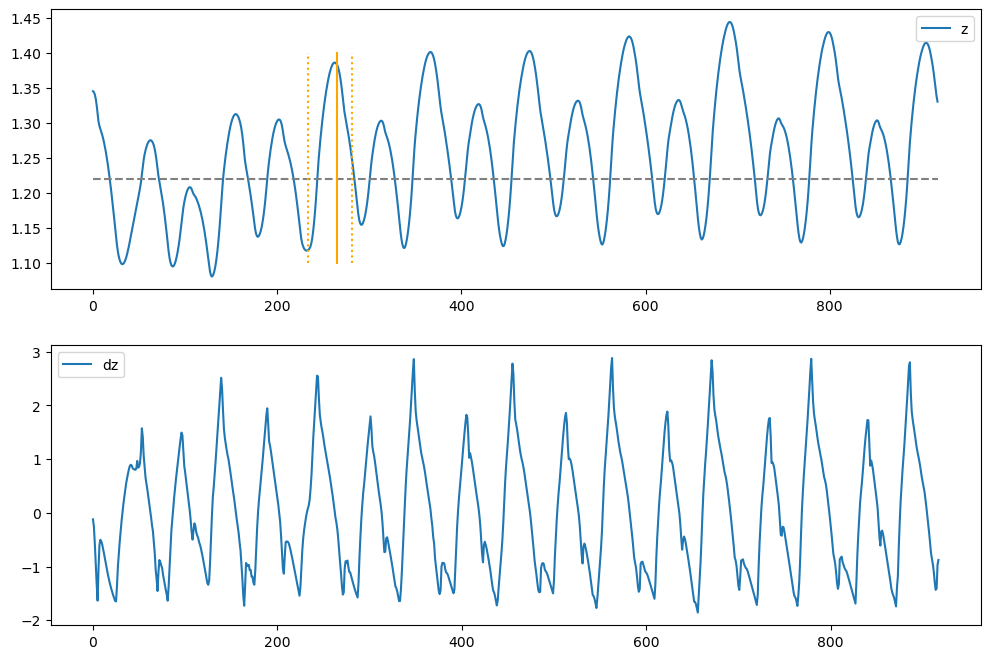

In [7]:
disp_start = 0
disp_end = traj_nsample - skip_nsample
regime_threshold = 1.22

back_nsample = 32
fore_nsample = 16
window_now = 265
window_start = window_now - back_nsample
window_end = window_now + fore_nsample

plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(env_traj[0][0, disp_start:disp_end, 0], label='z')
plt.plot([disp_start,disp_end],[regime_threshold, regime_threshold], linestyle='dashed', color='gray')
plt.plot([window_now, window_now], [1.1, 1.4], color='orange')
plt.plot([window_start, window_start],[1.1, 1.4], color='orange', linestyle='dotted')
plt.plot([window_end, window_end],[1.1, 1.4], color='orange', linestyle='dotted')
plt.legend()

plt.subplot(2,1,2)
plt.plot(env_traj[0][0, disp_start:disp_end, 9], label='dz')
plt.legend()

plt.show()

### Save data for baseline training

The baseline data contains all data, but without state breaks caused by MuJoco simulation restarts.

In [8]:
# --! combine all data to save it as 'no-break' data for baseline training
data_baseline_2x = torch.cat([traj for traj in env_traj], dim=0)
print(f'baseline 2x data shape: {data_baseline_2x.shape}')

# --! randomly extract a two-times smaller portion of data for training
ndata_baseline_1x = 40
data_baseline_1x_i = torch.randperm(len(data_baseline_2x))[:ndata_baseline_1x]
data_baseline_1x = data_baseline_2x[data_baseline_1x_i]
print(f'baseline 1x data shape: {data_baseline_1x.shape}')

# --! randomly extract smaller portion of data for evaluation
ndata_eval = 30
data_eval_i = torch.randperm(len(data_baseline_2x))[:ndata_eval]
data_eval = data_baseline_2x[data_eval_i]
print(f'evaluation data shape: {data_eval.shape}')

datasaved = True

if datasaved:
    write_datafile(f'{data_path}/baseline_2x', data_baseline_2x)
    write_datafile(f'{data_path}/baseline_1x', data_baseline_1x)
    write_datafile(f'{data_path}/eval', data_eval)

baseline 2x data shape: torch.Size([80, 918, 23])
baseline 1x data shape: torch.Size([40, 918, 23])
evaluation data shape: torch.Size([30, 918, 23])


### Extract and save nominal and excursion windows for KIND training

In [9]:
def nominal_criterion(sample, threshold=1.22):
    return sample > threshold

def excursion_criterion(sample, threshold=1.22):
    return sample < threshold

def extract_windows(timeseries, criterion, back_nsample, fore_nsample):

    windows = []

    timeseries_nsample = timeseries.shape[0]
    for i in range(timeseries_nsample):
        if criterion(timeseries[i, 0]):
            window_start = i - back_nsample
            window_end = i + fore_nsample
            if window_start >= 0 and window_end <= timeseries_nsample:
                window = timeseries[window_start:window_end, :]
                windows.append(window)

    return torch.stack(windows)

data_nom = [extract_windows(this_traj, nominal_criterion, back_nsample, fore_nsample) for traj in env_traj for this_traj in traj]
data_exc = [extract_windows(this_traj, excursion_criterion, back_nsample, fore_nsample) for traj in env_traj for this_traj in traj]

data_nom = torch.cat(data_nom, dim=0)
data_exc = torch.cat(data_exc, dim=0)

print(f'nominal data shape: {data_nom.shape}')
print(f'excursion data shape: {data_exc.shape}')

nominal data shape: torch.Size([43781, 48, 23])
excursion data shape: torch.Size([25899, 48, 23])


In [10]:
datasaved = True

if datasaved:
    write_datafile(f'{data_path}/nom', data_nom)
    write_datafile(f'{data_path}/exc', data_exc)